# <font color=#0099CC>**Investigación LdP — RNN: V_in = 5, V_out = 90**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Notebook individual para una única combinación del grid 4×4 (**V_in=5**, **V_out=90**), **rama de investigación**:

1. **Diferenciación fraccional** sobre `log(precio)` con `d = D_FRAC_INV = 0.40` en lugar de log-retornos. Preserva memoria de largo plazo manteniendo la estacionariedad ADF (ver `eleccion_d_fracionario.ipynb` para la justificación del valor).
2. **Split temporal con embargo** en lugar del split aleatorio de la competición. El embargo `H = V_in + V_out` descarta las muestras frontera entre train / val / test para eliminar el leakage por solapamiento de ventanas (Purged Split, LdP cap. 7).

**Salidas generadas**:

- `08_results/tablas/parciales/inv_rnn_vin5_vout90.csv` — métricas oficiales tras `load_weights` del best checkpoint.
- `08_results/curvas/inv_rnn/inv_rnn_vin5_vout90.png` — curva train/val con líneas horizontales del MAE val de los **baselines** si existen los CSV en `08_results/tablas/`.
- `08_results/runs/inv_rnn/inv_rnn_vin5_vout90/` — auditoría `BestRunTracker`: `last.json`, `best.json`, `history.csv`, `epoch_history.csv`, `best.keras` histórico; **no sustituye** el flujo oficial de checkpoints `.weights.h5`.
- `08_results/checkpoints/inv_rnn_vin5_vout90_best.weights.h5` — best checkpoint oficial guardado por `ModelCheckpoint`.


> <u>**Nota -  Unidades diferentes del MAE**</u>: al activar frac-diff, `create_dataset` deriva X e Y de la misma serie transformada, por lo que el MAE de los modelos de investigación está en *unidades de frac-diff*, no en log-retornos. Es internamente coherente pero no directamente comparable en valor absoluto con el MAE de los notebooks de competición. Comparar como *mejora relativa* contra un baseline trivial en la misma escala.
>
> <u>**Nota - Pérdida de muestras al inicio**</u>: la truncación FFD descarta las primeras `L-1` filas del histórico (con `d=0.40` y `threshold=1e-5`, del orden de centenas / pocos miles). Lo imprime `load_data(..., verbose=True)` al cargar.
>
> <u>**Nota - Embargo**</u>: La partición train/val/test es temporal con embargo (Purged Split, López de Prado 2018), no aleatoria. Train = 80 % cronológico inicial, Val = 10 % intermedio, Test = 10 % final; entre cada partición se descartan `V_in + V_out` muestras de embargo para eliminar el solapamiento de ventanas. Esto difiere del split aleatorio de la competición — los MAE absolutos no son directamente comparables entre tracks.


## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.


In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')


> Entorno : local
> BASE    : /mnt/c/Users/Javi/Desktop/MIAX/Entregas/Entrega 11 - Redes Neuronales/Taller4_DL_MIAX/Taller4_DL_MIAX
> SRC     : /mnt/c/Users/Javi/Desktop/MIAX/Entregas/Entrega 11 - Redes Neuronales/Taller4_DL_MIAX/Taller4_DL_MIAX/01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico, TensorFlow/Keras y utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from dataset_utils import (
    load_data, create_dataset, TICKERS,
    get_partitions_temporal, D_FRAC_INV, RANDOM_STATE_VAL,
)
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import (
    calc_mae_all,
    plot_curva,
    guardar_resultado_parcial,
    BestRunTracker,
    resumen_vs_baselines,
)

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')


2026-05-20 23:07:23.628830: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 23:07:23.642930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779311243.656638 1491009 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779311243.660351 1491009 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 23:07:23.675468: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

> TensorFlow : 2.18.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## <font color=#0099CC>**3. CONFIGURACIÓN DEL EXPERIMENTO**</font>

### <font color=#336699>**3.1. Combinación de ventanas e hiperparámetros**</font>

Única celda que cambia al duplicar el notebook para otro par **V_in / V_out**.


In [3]:
MODELO = 'inv_rnn'     # rama investigacion + arquitectura
V_IN, V_OUT = 5, 90

EPOCHS     = 5000
BATCH_SIZE = 100
PATIENCE   = 2500
SCALER     = 'standard'   # None | 'standard' | 'minmax'  (fit solo sobre X_tr)

N_ASSETS = len(TICKERS)

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}  |  scaler={SCALER}')


> Combinación: V_in=5, V_out=90  |  scaler=standard


## <font color=#0099CC>**4. DESCARGA DE DATOS**</font>

### <font color=#336699>**4.1. Serie multivariante, ventanas y particionado**</font>

Precios de cierre ajustados de los 23 activos vía `yfinance`, transformados con **frac-diff sobre `log(precio)`** con `d = D_FRAC_INV = 0.40` (FFD, López de Prado 2018). Las primeras `L-1` filas del histórico se descartan por la truncación FFD — `load_data(..., verbose=True)` imprime cuántas.

Se construyen las ventanas con `create_dataset` (idéntico a la competición) y se particiona con **`get_partitions_temporal`**: split cronológico ~80 / 10 / 10 con embargo `V_in + V_out` entre cada partición (Purged Split, LdP cap. 7). El `StandardScaler` se ajusta **solo sobre `X_tr`** y se aplica a train / val / test (`Y` no se escala — al ser frac-diff ya está centrada).


In [4]:
# Frac-diff de log(precio) con d = D_FRAC_INV (decidido en eleccion_d_fracionario.ipynb).
data, df = load_data(d_frac=D_FRAC_INV, verbose=True)
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos  '
      f'(escala: frac-diff, d={D_FRAC_INV})')
print(f'> Rango : {df.index[0].date()} -> {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT, verbose=True)

# Split TEMPORAL con embargo H = V_in + V_out (Purged Split, LdP cap. 7).
# El scaler se ajusta SOLO sobre X_tr (sin data-leakage); Y no se escala.
# `random_state=RANDOM_STATE_VAL` (=123) se pasa por coherencia con la
# legacy `get_partitions`; el split es determinista, así que no afecta.
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, scaler = get_partitions_temporal(
    X, Y, v_in=V_IN, v_out=V_OUT,
    scaler=SCALER, return_scaler=True,
    random_state=RANDOM_STATE_VAL, verbose=True,
)

print(f'> Shapes: X_tr {X_tr.shape}  X_val {X_val.shape}  X_test {X_test.shape}')
print(f'         Y_tr {Y_tr.shape}  Y_val {Y_val.shape}  Y_test {Y_test.shape}')


> Descargando datos desde 1945-01-01 hasta hoy...



[                       0%                       ]


[****                   9%                       ]  2 of 23 completed


[******                13%                       ]  3 of 23 completed


[********              17%                       ]  4 of 23 completed

...


[**********************87%*****************      ]  20 of 23 completed


[**********************91%*******************    ]  21 of 23 completed


[**********************96%*********************  ]  22 of 23 completed


[*********************100%***********************]  23 of 23 completed

> Frac-diff aplicada — d=0.4, L=1458 pesos, 1457 filas iniciales descartadas (~8.99% del histórico).
> Shape resultante: (14747, 23)
> Datos : 14,747 días × 23 activos  (escala: frac-diff, d=0.4)
> Rango : 1967-10-12 -> 2026-05-20
> Dataset creado — X: (14653, 5, 23), Y: (14653, 23)
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Split temporal con embargo  (v_in=5, v_out=90, embargo=95)
  Train   [     0,  11533)  ->   11533 muestras
  Val     [ 11628,  13093)  ->    1465 muestras  (gap previo: 95)
  Test    [ 13188,  14653)  ->    1465 muestras  (gap previo: 95)
  Descartadas por embargo: 190 muestras  (1.30% del total)
> Shapes: X_tr (11533, 5, 23)  X_val (1465, 5, 23)  X_test (1465, 5, 23)
         Y_tr (11533, 23)  Y_val (1465, 23)  Y_test (1465, 23)


## <font color=#0099CC>**5. MODELO RNN**</font>

### <font color=#336699>**5.1. Arquitectura y compilación**</font>

Capa `LSTM(64, recurrent_dropout=0.10)` sobre `(V_IN, 23)`, seguida de `Dense(64, relu)` + Dropout (0.30) y salida de 23 neuronas. Loss y métrica: `mae`. Arquitectura **idéntica** a `rnn_vin5_vout30.ipynb` (competición).


In [5]:
# Modelo CNN profundo: tres bloques Conv1D + GAP + cabeza densa.
# Padding 'same' → válido para cualquier V_IN >= 7.

def build_cnn(v_in, n_assets=N_ASSETS,
              filters_1=64, filters_2=128, filters_3=256,
              kernel_1=7, kernel_2=5, kernel_3=3,
              dense_units_1=256, dense_units_2=128,
              dropout_1=0.20, dropout_2=0.20,
              dropout_3=0.40, dropout_dense=0.60,
              l2_reg=1e-4,
              learning_rate=1e-4):

    l2 = regularizers.l2(l2_reg)

    model = keras.Sequential([
        layers.Input(shape=(v_in, n_assets)),

        layers.Conv1D(
            filters_1,
            kernel_1,
            padding='same',
            activation='relu',
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_1),

        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(
            filters_2,
            kernel_2,
            padding='same',
            activation='relu',
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_2),

        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(
            filters_3,
            kernel_3,
            padding='same',
            activation='relu',
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_3),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            dense_units_1,
            activation='relu'
        ),
        layers.Dropout(dropout_dense),

        layers.Dense(
            dense_units_2,
            activation='relu'
        ),
        layers.Dropout(dropout_dense),

        layers.Dense(n_assets),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae'],
    )

    return model


model = build_cnn(V_IN)
model.summary()

I0000 00:00:1779311252.352905 1491009 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,463 (990.09 KB)

 Trainable params: 252,567 (986.59 KB)

 Non-trainable params: 896 (3.50 KB)

## <font color=#0099CC>**6. ENTRENAMIENTO**</font>

### <font color=#336699>**6.1. Ajuste con callbacks**</font>

- `EarlyStopping` con `restore_best_weights` (corta el entrenamiento si `val_loss` no mejora en `PATIENCE` épocas).
- `ReduceLROnPlateau` cuando `val_loss` se estanca.
- `ModelCheckpoint` guarda **solo los pesos** del best epoch en `08_results/checkpoints/...weights.h5`.
- `BestRunTracker` (de `metrics_utils`) añade auditoría histórica en `08_results/runs/...` sin alterar el cierre oficial del entrenamiento (**siempre** `load_weights` desde `CKPT_PATH` al final).

Una sola combinación (sin bucle 4×4).


In [ ]:
CKPT_DIR = os.path.join(BASE, '08_results', 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(
    CKPT_DIR,
    f'{MODELO.lower()}_vin{V_IN}_vout{V_OUT}_best.weights.h5',
)

es = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=max(5, PATIENCE // 3),
    min_lr=1e-7,
    verbose=1,
)

mcp = ModelCheckpoint(
    filepath=CKPT_PATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

# Auditoría histórica (no toca el flujo oficial de checkpoints .h5)
run_tracker = BestRunTracker(
    MODELO, V_IN, V_OUT,
    datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test),
    hparams_extra={
        'epochs':                       EPOCHS,
        'batch_size':                   BATCH_SIZE,
        'patience_early_stopping':      PATIENCE,
        'patience_reduce_lr_plateau':   max(5, PATIENCE // 3),
        'scaler':                       SCALER,
        'weights_checkpoint':           CKPT_PATH,
    },
    auto_plot=False,
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, mcp, run_tracker],
    verbose=1,
)

# Restaurar los mejores pesos según val_loss (flujo oficial).
model.load_weights(CKPT_PATH)

print(f'> Epochs entrenadas        : {len(history.history["loss"])}')
print(f'> Best val_loss (MAE)      : {min(history.history["val_loss"]):.5f}')
print(f'> Pesos del modelo (best)  : {CKPT_PATH}')


## <font color=#0099CC>**7. MÉTRICAS Y PERSISTENCIA**</font>

### <font color=#336699>**7.1. MAE por partición, comparativa con baselines y guardado**</font>

MAE en train, val y test sobre el modelo ya restaurado al best checkpoint; se imprime la curva con las líneas del MAE val de los baselines (`buy_and_hold`, `trivial`, `lineal`) cuando existen sus CSV. Se imprime también la tabla `resumen_vs_baselines` con el % de mejora del modelo en test. Finalmente se persiste el CSV parcial (una fila) que después consolida `_agregador_*.ipynb`.


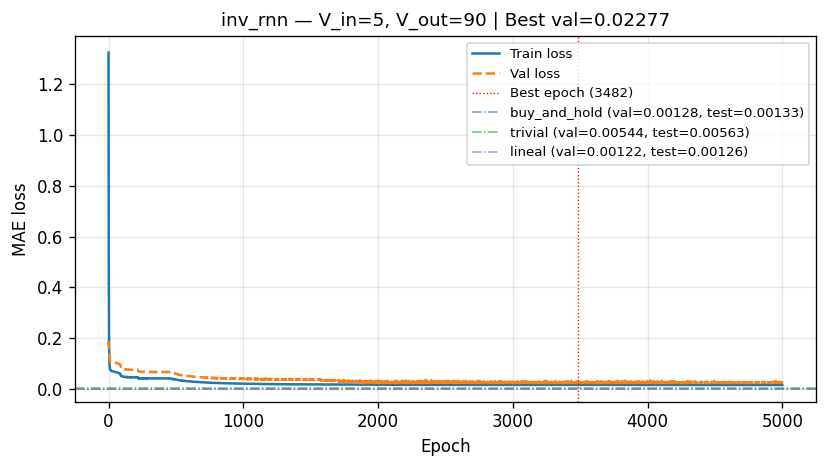

> Comparativa MAE — V_in=5, V_out=90


baseline,n_params,mae_train,mae_val,mae_test,mejora_test_%
inv_rnn,"253,463",0.01034,0.02246,0.03936,—
buy_and_hold,0,0.00131,0.00128,0.00133,-2867.78%
trivial,0,0.00554,0.00544,0.00563,-599.43%
lineal,"2,668",0.00123,0.00122,0.00126,-3020.44%



> Resultado parcial guardado: /mnt/c/Users/Javi/Desktop/MIAX/Entregas/Entrega 11 - Redes Neuronales/Taller4_DL_MIAX/Taller4_DL_MIAX/08_results/tablas/parciales/inv_rnn_vin5_vout90.csv

> MAE   train=0.01034   val=0.02246   test=0.03936   |   params=253,463


In [7]:
maes = calc_mae_all(model, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)

# Curva train/val + líneas horizontales de MAE val de los baselines
# (si los CSV de 08_results/tablas existen).
plot_curva(history, MODELO, V_IN, V_OUT, save=True, mostrar_baselines=True)
plt.show()

# Tabla comparativa MAE modelo vs baselines (train/val/test + % mejora).
resumen_vs_baselines(maes, V_IN, V_OUT, nombre_modelo=MODELO, n_params=model.count_params(), verbose=True)

resultado = {
    'modelo':    MODELO,
    'v_in':      V_IN,
    'v_out':     V_OUT,
    'n_params':  model.count_params(),
    'mae_train': maes['train'],
    'mae_val':   maes['val'],
    'mae_test':  maes['test'],
}

ruta = guardar_resultado_parcial(resultado, MODELO, V_IN, V_OUT, verbose=True)

print(f'\n> MAE   train={maes["train"]:.5f}   val={maes["val"]:.5f}   test={maes["test"]:.5f}'
      f'   |   params={model.count_params():,}')


## <font color=#0099CC>**8. CONSOLIDACIÓN**</font>

### <font color=#336699>**8.1. Heatmaps y tabla global**</font>

Los mapas de calor MAE y la tabla completa del modelo **RNN** de investigación no se generan aquí; ejecutar el agregador (`_agregador_inv_rnn.ipynb`) cuando existan los 6 CSV parciales en `08_results/tablas/parciales/`.
